In [2]:
import pandas as pd
from urllib.request import urlopen

import matplotlib.pyplot as plt
from PIL import Image

from mplsoccer import PyPizza, add_image, FontManager

from scipy import stats
import math

# Comando Mágico: Configura o pandas para exibir todas as colunas
pd.set_option('display.max_columns', None)

In [34]:
URL3 = 'https://github.com/VanillaandCream/Catamaran-Tamil/blob/master/Fonts/Catamaran-Medium.ttf?raw=true'
catamaran2 = FontManager(URL3)
URL = 'https://github.com/google/fonts/blob/main/ofl/fjallaone/FjallaOne-Regular.ttf?raw=true'
robotto_regular = FontManager(URL)
URL2 = 'https://github.com/VanillaandCream/Catamaran-Tamil/blob/master/Fonts/Catamaran-ExtraBold.ttf?raw=true'
catamaran = FontManager(URL2)

imagem = r"G:\pythonProject\Aula_Cbf\images\yuri_alberto.png"
fdj_cropped = Image.open(imagem)
#Use esta imagem para gerar imagens circulares: https://crop-circle.imageonline.co/

In [35]:
df = pd.read_csv(r'G:\pythonProject\Aula_Cbf\data\raw\stats_2024_Serie_A.csv')

In [36]:
df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90,Matches
0,1,Abner,br BRA,DF,Juventude,21-198,2004,18,13,1281,14.2,0,1,1,0,0,0,3,0,0.2,0.2,0.4,0.5,6,21,1,0.00,0.07,0.07,0.00,0.07,0.01,0.03,0.04,0.01,0.04,Matches
1,2,Nicolás Acevedo,uy URU,MF,Bahia,26-203,1999,25,13,1254,13.9,0,1,1,0,0,0,4,0,0.3,0.3,1.0,1.3,20,81,12,0.00,0.07,0.07,0.00,0.07,0.02,0.07,0.09,0.02,0.09,Matches
2,3,Luciano Acosta,ar ARG,"MF,FW",Fluminense,31-156,1994,10,9,751,8.3,2,0,2,2,0,0,3,0,1.8,1.8,1.5,3.3,16,56,41,0.24,0.00,0.24,0.24,0.24,0.21,0.19,0.40,0.21,0.40,Matches
3,4,Adson,br BRA,"FW,MF",Vasco da Gama,25-028,2000,10,0,210,2.3,0,0,0,0,0,0,0,0,0.1,0.1,0.2,0.4,6,12,17,0.00,0.00,0.00,0.00,0.00,0.05,0.10,0.15,0.05,0.15,Matches
4,5,Braian Aguirre,ar ARG,DF,Internacional,25-098,2000,25,24,2103,23.4,1,0,1,1,0,0,4,0,0.5,0.5,1.0,1.5,32,107,126,0.04,0.00,0.04,0.04,0.04,0.02,0.04,0.07,0.02,0.07,Matches


In [ ]:
# Definimos as condições de filtro
# Condição 1: A string 'MF' deve estar em qualquer parte da coluna 'Pos'
filtro_posicao = df['Pos'].str.contains('FW', case=False)

In [38]:
filtro_posicao.info()

<class 'pandas.core.series.Series'>
RangeIndex: 764 entries, 0 to 763
Series name: Pos
Non-Null Count  Dtype
--------------  -----
764 non-null    bool 
dtypes: bool(1)
memory usage: 896.0 bytes


In [7]:
# Condição 2: Os minutos jogados devem ser maiores que 350
minutos_minimos = 350
df['Min'] = pd.to_numeric(df['Min'], errors='coerce') # Usamos pd.to_numeric() para converter.
filtro_minutos = df['Min'] > minutos_minimos

In [39]:
# Aplicamos os dois filtros ao DataFrame usando o operador '&' (AND)
atacantes = df[filtro_posicao & filtro_minutos]

In [40]:
atacantes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 176 entries, 2 to 759
Data columns (total 37 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Rk           176 non-null    object
 1   Player       176 non-null    object
 2   Nation       176 non-null    object
 3   Pos          176 non-null    object
 4   Squad        176 non-null    object
 5   Age          176 non-null    object
 6   Born         176 non-null    object
 7   MP           176 non-null    object
 8   Starts       176 non-null    object
 9   Min          176 non-null    object
 10  90s          176 non-null    object
 11  Gls          176 non-null    object
 12  Ast          176 non-null    object
 13  G+A          176 non-null    object
 14  G-PK         176 non-null    object
 15  PK           176 non-null    object
 16  PKatt        176 non-null    object
 17  CrdY         176 non-null    object
 18  CrdR         176 non-null    object
 19  xG           176 non-null    objec

In [41]:
# Visualiza as primeiras linhas do novo DataFrame filtrado
atacantes.head(5)

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90,Matches
2,3,Luciano Acosta,ar ARG,"MF,FW",Fluminense,31-156,1994,10,9,751,8.3,2,0,2,2,0,0,3,0,1.8,1.8,1.5,3.3,16,56,41,0.24,0.00,0.24,0.24,0.24,0.21,0.19,0.40,0.21,0.40,Matches
6,7,Yuri Alberto,br BRA,FW,Corinthians,24-230,2001,21,16,1556,17.3,7,2,9,6,1,2,3,0,9.0,7.8,1.5,9.2,22,18,99,0.40,0.12,0.52,0.35,0.46,0.52,0.08,0.61,0.45,0.53,Matches
8,9,Alesson,br BRA,FW,Mirassol,26-260,1999,19,11,1059,11.8,4,5,9,4,0,0,1,0,4.7,4.7,1.9,6.6,38,27,104,0.34,0.42,0.76,0.34,0.76,0.40,0.17,0.56,0.40,0.56,Matches
14,15,Allan,br BRA,"MF,FW",Palmeiras,21-198,2004,21,4,567,6.3,1,2,3,1,0,0,0,1,0.7,0.7,0.6,1.3,14,17,29,0.16,0.32,0.48,0.16,0.48,0.12,0.09,0.20,0.12,0.20,Matches
15,16,Allan,br BRA,"MF,FW",Botafogo (RJ),34-299,1991,17,9,736,8.2,0,0,0,0,0,0,6,0,0.1,0.1,0.3,0.3,5,45,16,0.00,0.00,0.00,0.00,0.00,0.01,0.03,0.04,0.01,0.04,Matches


In [42]:
atacantes_plot = atacantes[['Player', 'xG_90', 'xAG_90','Gls_90', 'Ast_90', 'G+A_90', 'G-PK_90', 'G+A-PK_90', 'xG+xAG_90', 'npxG_90','npxG+xAG_90']].reset_index(drop=True)
atacantes_plot

,Player,xG_90,xAG_90,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG+xAG_90,npxG_90,npxG+xAG_90
0,Luciano Acosta,0.21,0.19,0.24,0.00,0.24,0.24,0.24,0.40,0.21,0.40
1,Yuri Alberto,0.52,0.08,0.40,0.12,0.52,0.35,0.46,0.61,0.45,0.53
2,Alesson,0.40,0.17,0.34,0.42,0.76,0.34,0.76,0.56,0.40,0.56
3,Allan,0.12,0.09,0.16,0.32,0.48,0.16,0.48,0.20,0.12,0.20
4,Allan,0.01,0.03,0.00,0.00,0.00,0.00,0.00,0.04,0.01,0.04
...,...,...,...,...,...,...,...,...,...,...,...
171,Wanderson,0.11,0.14,0.00,0.10,0.10,0.00,0.10,0.25,0.11,0.25
172,Deivid Washington,0.20,0.03,0.16,0.00,0.16,0.16,0.16,0.24,0.20,0.24
173,Wesley,0.17,0.13,0.00,0.22,0.22,0.00,0.22,0.30,0.17,0.30
174,Estêvão Willian,0.13,0.22,0.00,0.32,0.32,0.00,0.32,0.35,0.12,0.34


In [43]:
type(atacantes_plot)

pandas.core.frame.DataFrame

In [44]:
print(atacantes_plot)

                Player xG_90 xAG_90 Gls_90 Ast_90 G+A_90 G-PK_90 G+A-PK_90  \
0       Luciano Acosta  0.21   0.19   0.24   0.00   0.24    0.24      0.24   
1         Yuri Alberto  0.52   0.08   0.40   0.12   0.52    0.35      0.46   
2              Alesson  0.40   0.17   0.34   0.42   0.76    0.34      0.76   
3                Allan  0.12   0.09   0.16   0.32   0.48    0.16      0.48   
4                Allan  0.01   0.03   0.00   0.00   0.00    0.00      0.00   
..                 ...   ...    ...    ...    ...    ...     ...       ...   
171          Wanderson  0.11   0.14   0.00   0.10   0.10    0.00      0.10   
172  Deivid Washington  0.20   0.03   0.16   0.00   0.16    0.16      0.16   
173             Wesley  0.17   0.13   0.00   0.22   0.22    0.00      0.22   
174    Estêvão Willian  0.13   0.22   0.00   0.32   0.32    0.00      0.32   
175               Yago  0.05   0.07   0.00   0.16   0.16    0.00      0.16   

    xG+xAG_90 npxG_90 npxG+xAG_90  
0        0.40    0.21      

In [45]:
params = list(atacantes_plot.columns[1:]) 
params

['xG_90',
 'xAG_90',
 'Gls_90',
 'Ast_90',
 'G+A_90',
 'G-PK_90',
 'G+A-PK_90',
 'xG+xAG_90',
 'npxG_90',
 'npxG+xAG_90']

In [46]:
print(atacantes_plot[params].dtypes)

xG_90          object
xAG_90         object
Gls_90         object
Ast_90         object
G+A_90         object
G-PK_90        object
G+A-PK_90      object
xG+xAG_90      object
npxG_90        object
npxG+xAG_90    object
dtype: object


In [47]:
# Converter todas as colunas em `params` para numéricas
atacantes_plot[params] = atacantes_plot[params].apply(pd.to_numeric, errors='coerce')

In [48]:
jogador = list(atacantes_plot[atacantes_plot['Player'] == 'Yuri Alberto'].iloc[0].values[1:])
jogador

[np.float64(0.52),
 np.float64(0.08),
 np.float64(0.4),
 np.float64(0.12),
 np.float64(0.52),
 np.float64(0.35),
 np.float64(0.46),
 np.float64(0.61),
 np.float64(0.45),
 np.float64(0.53)]

In [49]:
values = []
for x in range(len(params)):   
    values.append(math.floor(stats.percentileofscore(atacantes_plot[params[x]],jogador[x])))

values

[93, 31, 85, 51, 80, 84, 73, 90, 94, 89]

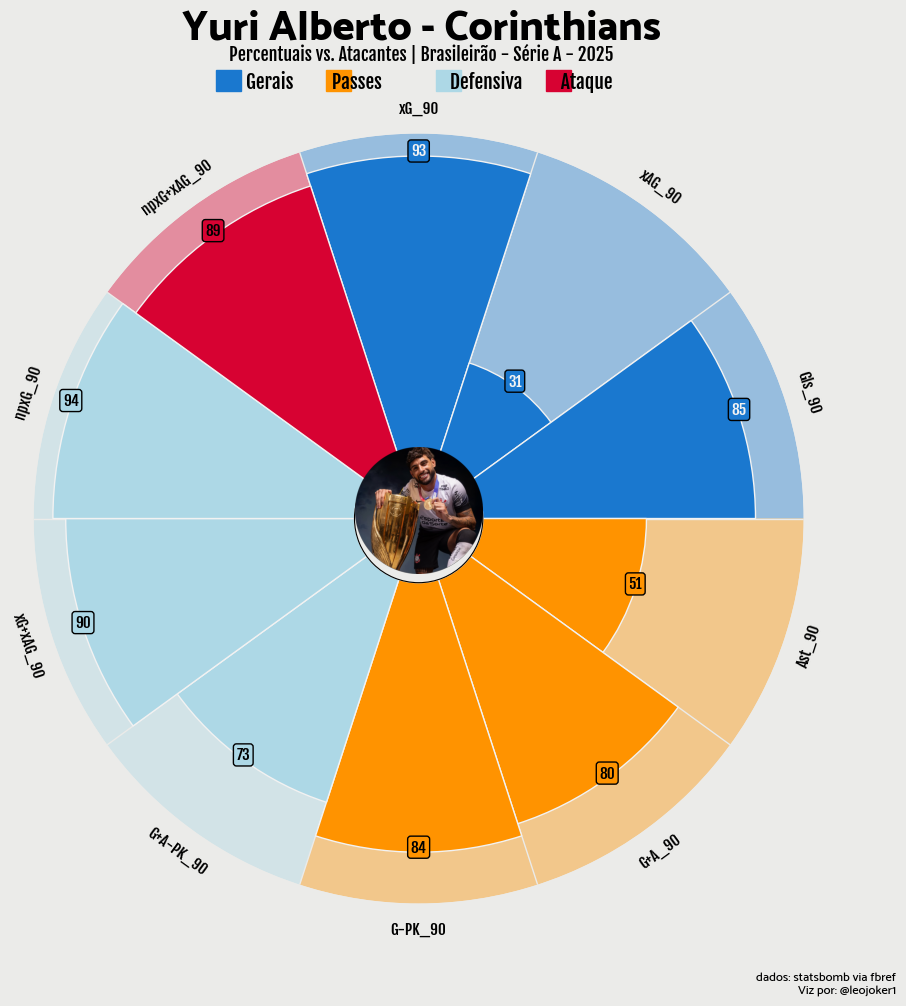

In [50]:
# lista de parâmetros --> já definida

# lista de valores --> já definida
# Os valores foram obtidos do excelente site fbref (fornecidos pela StatsBomb)

# cores para as fatias e para o texto
slice_colors = ["#1A78CF"] * 3 + ["#FF9300"] * 3 + ['lightblue'] * 3 + ["#D70232"] * 1
text_colors = ["#F2F2F2"] * 3 + ["#000000"] * 7  # Corrigido: total deve ser 10 (3 + 7 = 10)

# instanciar a classe PyPizza
baker = PyPizza(
    params=params,                  # lista de parâmetros
    background_color="#EBEBE9",     # cor de fundo
    straight_line_color="#EBEBE9",  # cor das linhas retas
    straight_line_lw=1,             # espessura das linhas retas
    last_circle_lw=0,               # espessura da última circunferência
    other_circle_lw=0,              # espessura das demais circunferências
    inner_circle_size=20            # tamanho do círculo interno
)

# gerar o gráfico de pizza
fig, ax = baker.make_pizza(
    values,                          # lista de valores
    figsize=(10, 10),                # ajuste o tamanho conforme necessário
    color_blank_space="same",        # usar a mesma cor para preencher o espaço vazio
    slice_colors=slice_colors,       # cores individuais para cada fatia
    value_colors=text_colors,        # cores do texto dos valores
    value_bck_colors=slice_colors,   # cores de fundo dos textos dos valores
    blank_alpha=0.4,                 # transparência para os espaços vazios
    kwargs_slices=dict(
        edgecolor="#F2F2F2", zorder=2, linewidth=1
    ),                               # configurações usadas ao plotar as fatias
    kwargs_params=dict(
        color="#000000", fontsize=11,
        fontproperties=robotto_regular.prop, va="center"
    ),                               # configurações para os rótulos dos parâmetros
    kwargs_values=dict(
        color="#000000", fontsize=11,
        fontproperties=robotto_regular.prop, zorder=3,
        bbox=dict(
            edgecolor="#000000", facecolor="cornflowerblue",
            boxstyle="round,pad=0.2", lw=1
        )
    )                                # configurações para os textos dos valores
)

# adicionar título
fig.text(
    0.515, 0.975, "Yuri Alberto - Corinthians", size=30,
    ha="center", fontproperties=catamaran.prop, color="#000000"
)

# adicionar subtítulo
fig.text(
    0.515, 0.953,
    "Percentuais vs. Atacantes | Brasileirão - Série A - 2025",
    size=13,
    ha="center", fontproperties=robotto_regular.prop, color="#000000"
)

# adicionar créditos
CREDIT_1 = "dados: statsbomb via fbref"
CREDIT_2 = "Viz por: @leojoker1"

fig.text(
    0.99, 0.02, f"{CREDIT_1}\n{CREDIT_2}", size=9,
    fontproperties=catamaran2.prop, color="#000000",
    ha="right"
)

# adicionar rótulos de categorias
fig.text(
    0.34, 0.925, "Gerais         Passes                Defensiva         Ataque", size=14,
    fontproperties=robotto_regular.prop, color="#000000"
)

# adicionar retângulos coloridos (indicadores de categoria)
fig.patches.extend([
    plt.Rectangle(
        (0.31, 0.9225), 0.025, 0.021, fill=True, color="#1a78cf",
        transform=fig.transFigure, figure=fig
    ),
    plt.Rectangle(
        (0.42, 0.9225), 0.025, 0.021, fill=True, color="#ff9300",
        transform=fig.transFigure, figure=fig
    ),
    plt.Rectangle(
        (0.53, 0.9225), 0.025, 0.021, fill=True, color="lightblue",
        transform=fig.transFigure, figure=fig
    ),
    plt.Rectangle(
        (0.64, 0.9225), 0.025, 0.021, fill=True, color="#d70232",
        transform=fig.transFigure, figure=fig
    ),
])

# adicionar imagem (ex: escudo ou foto do jogador)
ax_image = add_image(
    fdj_cropped, fig, left=0.4478, bottom=0.44, width=0.13, height=0.127
)   # esses valores podem variar dependendo do seu gráfico

plt.show()